In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")

print("Path to dataset files:", path)

c:\Users\yamaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\radheshyamkollipara\bank-customer-churn\versions\1


In [2]:
import pandas as pd
import os

files = os.listdir(path)

csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# 表示
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [5]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [6]:
# 予測に関係ない列を削除
df_clean = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [7]:
# 性別のエンコーディング（Female=0, Male=1）
df_clean["Gender"] = df_clean["Gender"].map({"Female": 0, "Male": 1})

# 居住国のエンコーディング（ダミー変数化）
df_clean = pd.get_dummies(df_clean, columns=["Geography"], drop_first=True)

# カード種別のエンコーディング
card_map = {"SILVER": 0, "GOLD": 1, "PLATINUM": 2, "DIAMOND": 3}
df_clean["Card Type"] = df_clean["Card Type"].map(card_map)

df_clean.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,3,464,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,3,456,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,3,377,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,False,True


In [8]:
# 列名を日本語に変換する
name_mapping = {
    "CreditScore": "信用スコア",
    "Gender": "性別",
    "Age": "年齢",
    "Tenure": "継続年数",
    "Balance": "預金残高",
    "NumOfProducts": "製品利用数",
    "HasCrCard": "カード保有",
    "IsActiveMember": "アクティブ会員",
    "EstimatedSalary": "推定年収",
    "Exited": "離脱",
    "Complain": "苦情有無",
    "Satisfaction Score": "満足度スコア",
    "Card Type": "カード種別",
    "Point Earned": "獲得ポイント",
    "Geography_Germany": "ドイツ居住",
    "Geography_Spain": "スペイン居住"
}

df_clean = df_clean.rename(columns=name_mapping)

df_clean.head()

,信用スコア,性別,年齢,継続年数,預金残高,製品利用数,カード保有,アクティブ会員,推定年収,離脱,苦情有無,満足度スコア,カード種別,獲得ポイント,ドイツ居住,スペイン居住
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,3,464,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,3,456,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,3,377,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,False,True


In [9]:
from sklearn.model_selection import train_test_split

# 目的変数と説明変数に分ける
X = df_clean.drop(["離脱", "苦情有無", "満足度スコア"], axis=1)
y = df_clean["離脱"]

# 学習用データとテスト用データに分割（８：２の割合）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"学習用データの数：{len(X_train)}件")
print(f"テスト用データの数：{len(X_test)}件")

学習用データの数：8000件
テスト用データの数：2000件


In [10]:
from sklearn.tree import DecisionTreeClassifier

# モデルを作成する
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# 学習
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

In [11]:
import pandas as pd
from sklearn.metrics import classification_report

# 評価レポートの表示
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict)

print("--- 評価レポート ---")
display(report_df.round(3))

--- 評価レポート ---


,0,1,accuracy,macro avg,weighted avg
precision,0.863,0.766,0.854,0.814,0.844
recall,0.973,0.366,0.854,0.670,0.854
f1-score,0.914,0.496,0.854,0.705,0.832
support,1607.000,393.000,0.854,2000.000,2000.000


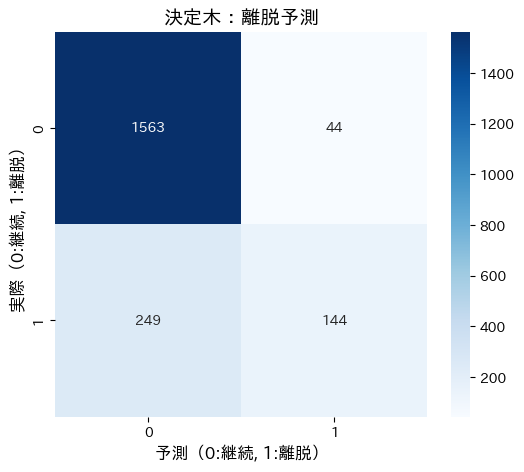

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# 混合行列の計算
cm = confusion_matrix(y_test, y_pred)

# グラフの設定
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("決定木：離脱予測", fontsize=14)
plt.xlabel("予測（0:継続, 1:離脱）", fontsize=12)
plt.ylabel("実際（0:継続, 1:離脱）", fontsize=12)

plt.show()

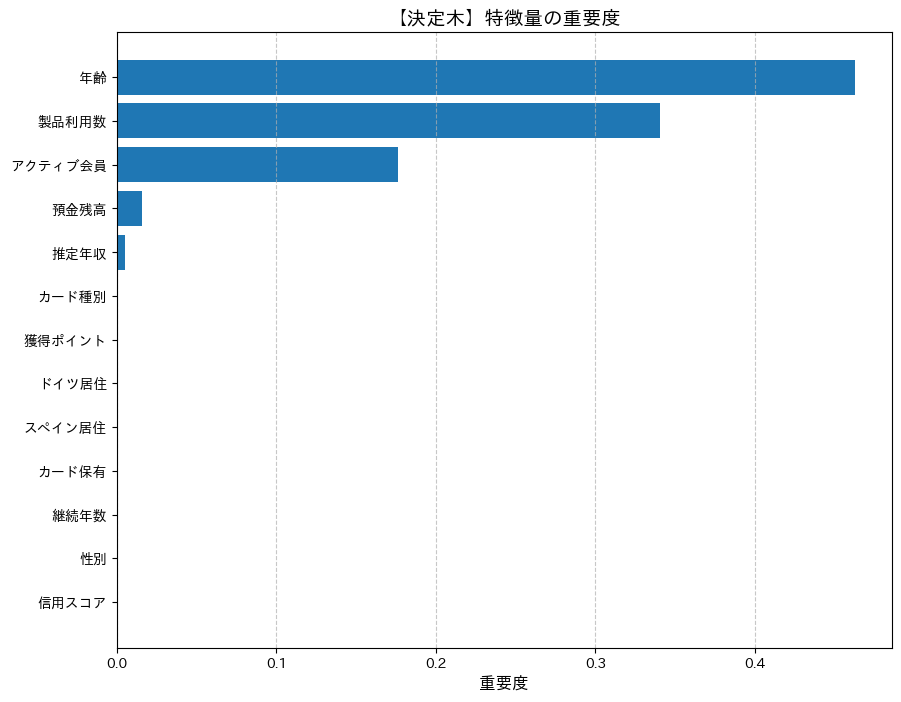

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import alpha

# 重要度の取得と並び替え
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

# 可視化
plt.figure(figsize=(10, 8))
plt.title("【決定木】特徴量の重要度", fontsize=14)
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("重要度", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()


In [14]:
from turtle import mode
from sklearn.ensemble import RandomForestClassifier

# モデルの作成
model_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

# 学習
model_rf.fit(X_train, y_train)

# 予測
y_pred_rf = model_rf.predict(X_test)

In [15]:
from sklearn.metrics import classification_report
import pandas as pd

report_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True)
report_rf_df = pd.DataFrame(report_rf_dict)

print("--- ランダムフォレスト 評価レポート ---")
display(report_rf_df.round(3))

--- ランダムフォレスト 評価レポート ---


,0,1,accuracy,macro avg,weighted avg
precision,0.840,0.873,0.842,0.856,0.846
recall,0.992,0.226,0.842,0.609,0.842
f1-score,0.910,0.360,0.842,0.635,0.801
support,1607.000,393.000,0.842,2000.000,2000.000


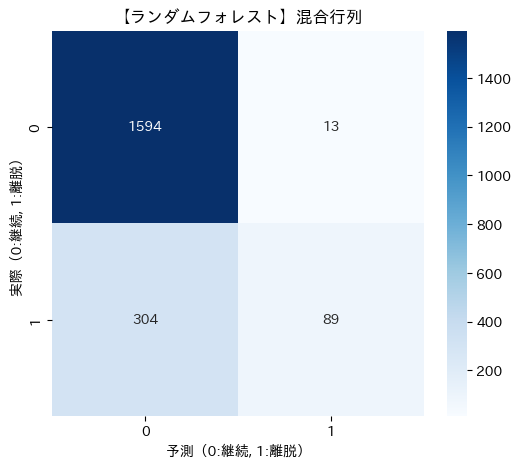

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 混合行列の計算
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 可視化
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.title("【ランダムフォレスト】混合行列")
plt.xlabel("予測（0:継続, 1:離脱）")
plt.ylabel("実際（0:継続, 1:離脱）")
plt.show()

In [17]:
# 離脱する確率を直接計算する
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# しきい値を0.5から0.3に下げる
threshold = 0.3
y_pred_tuned = (y_proba_rf >= threshold).astype(int)

# 評価レポートを表示
report_tuned_dict = classification_report(y_test, y_pred_tuned, output_dict=True)
report_tuned_df = pd.DataFrame(report_tuned_dict)

print("--- ランダムフォレスト（しきい値0.3）評価レポート ---")
display(report_tuned_df.round(3))

--- ランダムフォレスト（しきい値0.3）評価レポート ---


,0,1,accuracy,macro avg,weighted avg
precision,0.895,0.677,0.86,0.786,0.852
recall,0.936,0.550,0.86,0.743,0.860
f1-score,0.915,0.607,0.86,0.761,0.854
support,1607.000,393.000,0.86,2000.000,2000.000


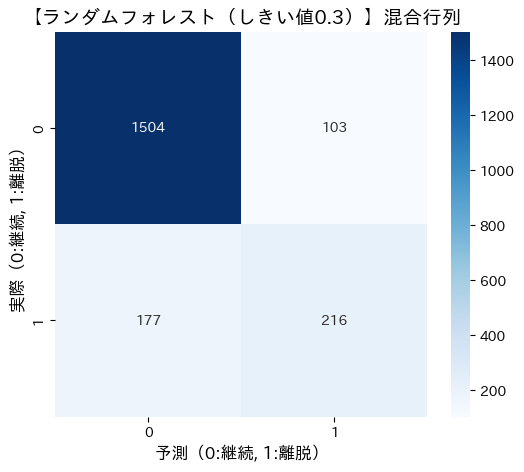

In [18]:
# 調整後の予測結果で混合行列を計算
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# 可視化
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues")

plt.title("【ランダムフォレスト（しきい値0.3）】混合行列", fontsize=14)
plt.xlabel("予測（0:継続, 1:離脱）", fontsize=12)
plt.ylabel("実際（0:継続, 1:離脱）", fontsize=12)

plt.show()

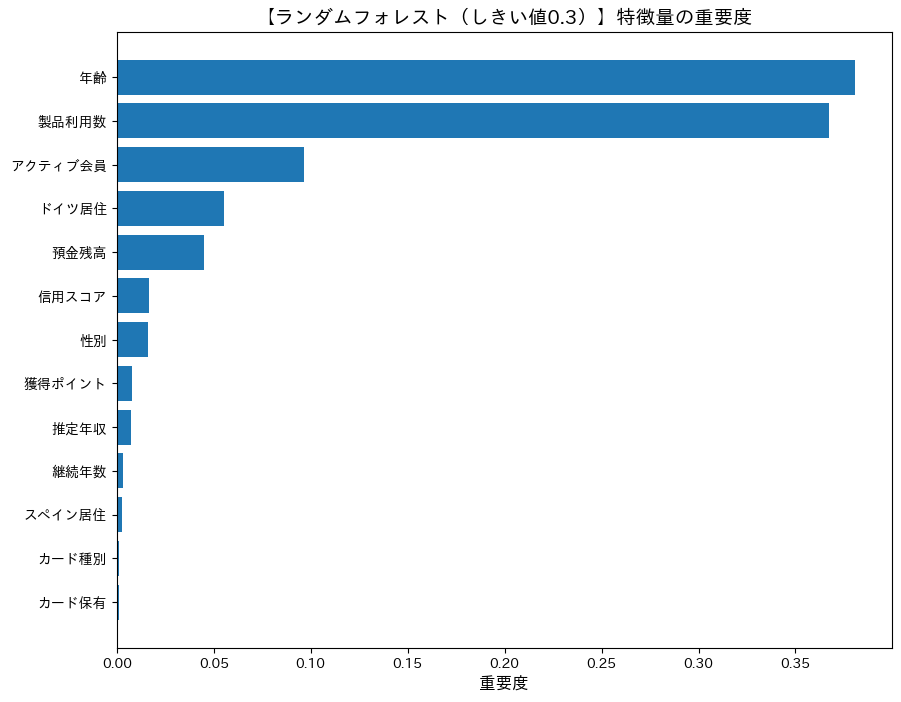

In [19]:
# ランダムフォレストの重要度を取得
from matplotlib.lines import lineStyles


importances_rf = model_rf.feature_importances_
feature_names = X.columns
indices_rf = np.argsort(importances_rf)

# 可視化
plt.figure(figsize=(10, 8))
plt.title("【ランダムフォレスト（しきい値0.3）】特徴量の重要度", fontsize=14)
plt.barh(range(len(indices_rf)), importances_rf[indices_rf])
plt.yticks(range(len(indices_rf)), [feature_names[i] for i in indices_rf] )
plt.xlabel("重要度", fontsize=12)


plt.show()

In [20]:
import lightgbm as lgb
from sklearn.metrics import classification_report

train_data = lgb.Dataset(X_train, label=y_train)

# パラメータの設定
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "random_state": 42,
    "learning_rate": 0.05
}

# 学習
model_lgb = lgb.train(params, train_data, num_boost_round=100)

# 予測
y_proba_lgb = model_lgb.predict(X_test)

# 予測
y_proba_lgb = model_lgb.predict(X_test)

# しきい値を「0.3」に設定
y_pred_lgb = (y_proba_lgb >= 0.3).astype(int)

In [21]:
report_lgb_dict = classification_report(y_test, y_pred_lgb, output_dict=True)
report_lgb_df = pd.DataFrame(report_lgb_dict)

print("--- LightGBM（しきい値0.3）評価レポート ---")
display(report_lgb_df.round(3))

--- LightGBM（しきい値0.3）評価レポート ---


,0,1,accuracy,macro avg,weighted avg
precision,0.920,0.608,0.851,0.764,0.858
recall,0.892,0.682,0.851,0.787,0.851
f1-score,0.906,0.643,0.851,0.774,0.854
support,1607.000,393.000,0.851,2000.000,2000.000


Text(46.722222222222214, 0.5, '実際（0:継続, 1:離脱）')

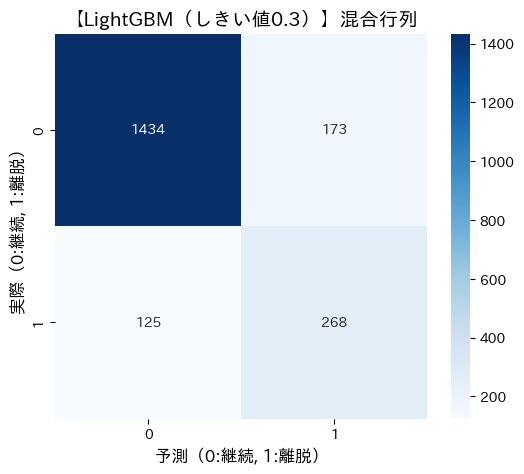

In [22]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

# 可視化
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues")

plt.title("【LightGBM（しきい値0.3）】混合行列", fontsize=14)
plt.xlabel("予測（0:継続, 1:離脱）", fontsize=12)
plt.ylabel("実際（0:継続, 1:離脱）", fontsize=12)

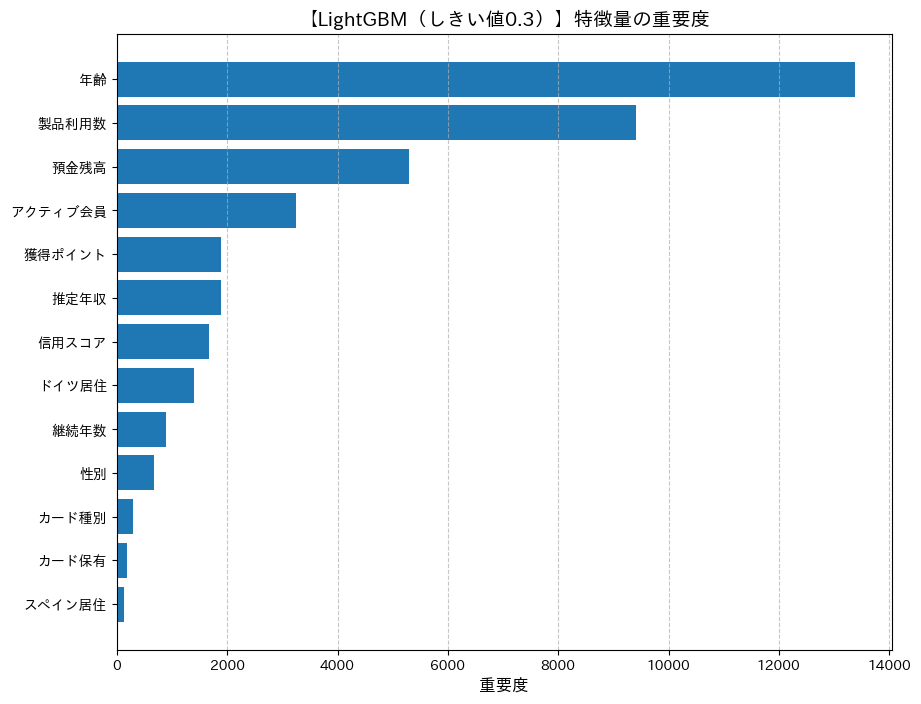

In [23]:
# 重要度を取得
importances_lgb = model_lgb.feature_importance(importance_type="gain")
feature_names = X.columns
indices_lgb = np.argsort(importances_lgb)

# 可視化
plt.figure(figsize=(10, 8))
plt.title("【LightGBM（しきい値0.3）】特徴量の重要度", fontsize=14)
plt.barh(range(len(indices_lgb)), importances_lgb[indices_lgb])
plt.yticks(range(len(indices_lgb)), [feature_names[i] for i in indices_lgb])
plt.xlabel("重要度", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

In [42]:
# 残高の余裕度
df_clean["残高年収比率"] = df_clean["預金残高"] / df_clean["推定年収"]
df_clean["1製品あたりの預金額"] = df_clean["預金残高"] / df_clean["製品利用数"]
df_clean["シニアフラグ"] = (df_clean["年齢"] >= 60).astype(int)



In [47]:
# 学習
params = {
    "objective" : "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "random_state": 42
}



In [48]:
# 学習
model_new = lgb.train(params, train_data)

# 予測
y_proba_final = model_new.predict(X_test)

# しきい値0.3
y_pred_final = (y_proba_final >= 0.3).astype(int)

# 評価レポート表示
from sklearn.metrics import classification_report
import pandas as pd

# 予測結果 (y_pred_final) を使ってレポートを作成
final_report_dict = classification_report(y_test, y_pred_final, output_dict=True)
final_report_df = pd.DataFrame(final_report_dict)

print("--- 【特徴量追加】LightGBM（しきい値0.3）評価レポート ---")
display(final_report_df.round(3))

--- 【特徴量追加】LightGBM（しきい値0.3）評価レポート ---


,0,1,accuracy,macro avg,weighted avg
precision,0.915,0.603,0.848,0.759,0.854
recall,0.894,0.662,0.848,0.778,0.848
f1-score,0.904,0.631,0.848,0.768,0.851
support,1607.000,393.000,0.848,2000.000,2000.000
